<h1 align='center'> 영상처리 프로그래밍 실습 3</h1>

<h6 align='right'> 2025. 3. 27. </h6>

<div class="alert alert-block alert-info">
    
- 파일 이름에서 00000000을 자신의 학번으로, name을 자신의 이름으로 수정하세요.

- 다음 줄에 자신의 이름, 학번, 학과(전공)을 적으세요.

* 이름:  이한석          학번:   20215226         학과(전공):  빅데이터학과
    
</div>

- JupyterLab 문서의 최신 버전은 [JupyterLab Documentation](https://jupyterlab.readthedocs.io/en/stable/index.html#/)을  참고하라

- Markdown은 [Markdown Guide](https://www.markdownguide.org/)를 참고하라.
- [Markdown Cheat Sheet](https://www.markdownguide.org/cheat-sheet/)

* 제출 마감: 4월 2일 (수) 오후 10:00까지 최종본을 SmartLEAD제출


In [2]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import sys

print("Python version", sys.version)
print("OpenCV version", cv2.__version__)
print("NumPy version", np.__version__)

Python version 3.9.2 (tags/v3.9.2:1a79785, Feb 19 2021, 13:44:55) [MSC v.1928 64 bit (AMD64)]
OpenCV version 4.11.0
NumPy version 2.0.2


## 문제 1. 기본 이미지 읽기와 표시
* 목표: OpenCV로 이미지 파일을 읽고 창에 표시하는 기본 동작 이해

### 1.1 
OpenCV의 imread() 함수를 이용해서 tree-1.jpg 파일을 읽고, 화면에 표시하는 프로그램을 작성하라. 



In [9]:
import cv2 

#이미지 읽기
tree_1 = cv2.imread('tree-1.jpg')

#이미지 표시
cv2.imshow('Tree 1',tree_1) #'tree_1'이미지를 'Tree 1'이라는 윈도우 제목으로 화면에 표시
cv2.waitKey(0)  #키보드 입력 기다리기, 0은 무한히 기다림
#cv2.destroyAllWindows() #열린 모든 OpenCV윈도우 닫기
cv2.destroyWindow('Tree 1')

### namedWindows 함수 사용하기

In [ ]:
import cv2

tree_1 = cv2.imread('tree-1.jpg') #이미지 읽어오기
cv2.namedWindow('Tree 1', 0) #'Tree 1'이라는 윈도우 창 생성, 0 -> 윈도우 크기 재조정 가능 , 기본값 1 -> 표시될 영상의 크기에 맞춰 윈도우 크기 자동 조정 재조정 X
#cv2.WINDOW_NORMAL 0
#cv2.WINDOW_AUTOSIZE 1
cv2.imshow('Tree 1', tree_1)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [21]:
for e in dir(cv2):
    if 'WINDOW_' in e:
        print(e)

WINDOW_AUTOSIZE
WINDOW_FREERATIO
WINDOW_FULLSCREEN
WINDOW_GUI_EXPANDED
WINDOW_GUI_NORMAL
WINDOW_KEEPRATIO
WINDOW_NORMAL
WINDOW_OPENGL


### 1.2:
namedWindow 함수를 사용하는 경우에 윈도우 크기가 작은 이유를 알아 보고, namedWindow 함수를 사용했을 때도 윈도우 크기가 영상의 크기에 맞게 표시되도록 프로그램을 수정하라.

In [25]:
#namedWindow 함수가 윈도우를 생성할 떄 크기를 자동으로 영상에 맞추지 않고,
#디폴트 크기(보통 작은 크기)로 설정해서

import cv2

tree_1 = cv2.imread('tree-1.jpg')
height, width = tree_1.shape[:2] #(높이, 너비, 채널 수)
print(height)
print(width)

window_name = 'Tree 1'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL) #cv2.WINDOW_NORMAL 윈도우 크기가 영상 크기에 맞게 표기
cv2.imshow(window_name, tree_1)
cv2.resizeWindow(window_name, width, height)
#윈도우 크기를 영상의 원본 크기에 맞게 조정
#영상이 축소되거나 잘리지 않고 원본크기로 표시
#윈도우를 생성할 떄 cv2.WINDOW_NORMAL로 생성해야함

cv2.waitKey(0)
cv2.destroyAllWindows()

426
640


### 1.3
이 프로그램에서 waitKey(0)의 역할을 설명하라.

In [ ]:
#사용자가 키보드를 눌러 입력할 때까지 프로그램을 대기시키는 것

### [심화] 1.4
앞에서 작성한 프로그램에서 cv2.imread 함수로 이미지를 읽을 때, 지정한 파일('tree-1.jpg')이 존재하지 않으면 오류가 발생한다. 파일이 없는 경우를 대비해 프로그램이 비정상 종료되지 않도록 오류 메시지를 출력하는 기능을 추가하라.

In [26]:
import cv2

tree_1 = cv2.imread('tree-11.jpg')  #파일 못 찾으면 None 반환

cv2.imshow('Tree 1', tree_1)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'cv::imshow'


In [27]:
type(tree_1)

NoneType

In [28]:
tree_1 == None

True

In [30]:
import cv2

tree_1 = cv2.imread('tree-11.jpg')  #파일 못 찾으면 None 반환

if tree_1 == None:  #파일을 못 찾으면
    print("Error : Could not load tree-11.jpg") #에러 메세지 출력
else:
    cv2.imshow('Tree 1', tree_1)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

Error : Could not load tree-11.jpg


In [ ]:
import cv2

try:
    tree_1 = cv2.imread('tree-11.jpg')  # 파일 못 찾으면 None 반환
    if tree_1 is None:
        raise FileNotFoundError("Could not load tree-11.jpg") #FileNotFoundError 예외 발생, 에러메세지 출력

except FileNotFoundError as e:
    print(f"Error: {e}")
    
except Exception as e: #FileNotFoundError 이외의 기타 예외
    print(f"An unexpected error occurred: {e}")
    
else:
    cv2.imshow('Tree 1', tree_1)
    cv2.waitKey(0)
    
finally:
    cv2.destroyAllWindows()

Error:  not load tree-11.jpg


## 문제 2.
 * 목표: 두 이미지 간의 간단한 전환 효과 이해
   
### 2.1
OpenCV의 imread() 함수를 이용해서 tree-1.jpg와 tree-2.jpg를 읽고, 가중치 $\alpha$를 1부터 0까지 0.01 간격으로 변경해 가면서, 두 영상의 weighted sum을 차례로 구하고 화면에 표시하는 프로그램을 작성하라. 

단, 영상과 영상 사이의 디스플레이 간격은 0.05초로 설정하라.


In [1]:
import cv2
import numpy as np

tree_1=cv2.imread('tree-1.jpg') #이미지 읽어오기
tree_2=cv2.imread('tree-2.jpg')
    
cv2.imshow('Blended Image', tree_1) #Blended Image 창에 tree_1 표시
cv2.waitKey(0)
    
for alpha in np.arange(0,1,0.01): #0부터 1까지 0.01 간격
    blended = (1-alpha)*tree_1 + alpha*tree_2 #tree_1과 tree_2 이미지를 가중합하여 새로운 이미지 생성 float
    cv2.imshow("Blended Image", blended.astype(np.uint8)) #OpenCV는 uint8 형태
    if cv2.waitKey(50)==ord('q'): #cv2.waitKey(50)의 반환 값이 'q' 키의 ASCII 값인 113인지 확인 ord('q') ASCII 값 반환
        break                     #q 누르면 113
cv2.destroyAllWindows()

### [심화] 2.2 

문제 2.1에서 만든 프로그램 그림에서 발생할 수 있는 예외적인 상황에 대해서 생각해 보고, 이런 상황을 처리하도록 프로그램을 수정하라.



In [2]:
import cv2
import numpy as np

try:
    tree_1=cv2.imread('tree-1.jpg') #이미지 읽어오기
    tree_2=cv2.imread('tree-2.jpg')
    if tree_1 is None or tree_2 is None: #이미지 못 읽으면
        raise FileNotFoundError("Could not load file.")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
else: #예외가 없으면
    cv2.imshow('Blended Image', tree_1) #Blended Image 창에 tree_1 표시
    cv2.waitKey(0)
    
    for alpha in np.arange(0,1,0.01): #0부터 1까지 0.01 간격
        blended = (1-alpha)*tree_1 + alpha*tree_2 #tree_1과 tree_2 이미지를 가중합하여 새로운 이미지 생성 float
        cv2.imshow("Blended Image", blended.astype(np.uint8)) #OpenCV는 uint8 형태
        if cv2.waitKey(50)==ord('q'): #cv2.waitKey(50)의 반환 값이 'q' 키의 ASCII 값인 113인지 확인 ord('q') ASCII 값 반환
            break                     #q 누르면 113

finally: 
    cv2.destroyAllWindows()

## 문제 3.
 * 목표: 네 개 이미지 간 순환 전환 구현

OpenCV의 imread() 함수를 이용해서 tree-1.jpg, tree-2.jpg, tree-3.jpg,  tree-4.jpg 네 파일을 읽고, 가중치 $\alpha$를 1부터 0까지 0.01 간격으로 변경해 가면서, 다음 () 안의 두 영상의 weighted sum을 차례로 구하고 화면에 표시하는 프로그램을 작성하라. 

- (tree-1.jpg, tree-2.jpg) --> (tree-2.jpg, tree-3.jpg) --> (tree-3.jpg, tree-4.jpg) --> (tree-4.jpg, tree-1.jpg)

단, 영상과 영상 사이의 디스플레이 간격은 0.05초로 설정하라.


In [ ]:
import numpy as np
import cv2

try: #이미지 읽어오기
    filename = 'tree-1.jpg'
    tree_1 = cv2.imread(filename)
    if tree_1 is None:
        raise ValueError(f"Could not load {filename}")

    filename = 'tree-2.jpg'
    tree_2 = cv2.imread(filename)
    if tree_2 is None:
        raise ValueError(f"Could not load {filename}")

    filename = 'tree-3.jpg'
    tree_3 = cv2.imread(filename)
    if tree_3 is None:
        raise ValueError(f"Could not load {filename}")

    filename = 'tree-4.jpg'
    tree_4 = cv2.imread(filename)
    if tree_4 is None:
        raise ValueError(f"Could not load {filename}")

except Exception as e: #예외
    print(f"An error occurred: {e}")

else: 
    for alpha in np.arange(0, 1, 0.01): #0부터 1까지 0.01
        blended = ((1 - alpha) * tree_1 + alpha * tree_2).astype(np.uint8) #tree1 -> tree2
        cv2.imshow('Blended images', blended)
        cv2.waitKey(50)

    for alpha in np.arange(0, 1, 0.01):
        blended = ((1 - alpha) * tree_2 + alpha * tree_3).astype(np.uint8) #tree2 -> tree3
        cv2.imshow('Blended images', blended)
        cv2.waitKey(50)

    for alpha in np.arange(0, 1, 0.01):
        blended = ((1 - alpha) * tree_3 + alpha * tree_4).astype(np.uint8) #tree3 -> tree4
        cv2.imshow('Blended images', blended)
        cv2.waitKey(50)

    for alpha in np.arange(0, 1, 0.01):
        blended = ((1 - alpha) * tree_4 + alpha * tree_1).astype(np.uint8) #tree4 -> tree1
        cv2.imshow('Blended images', blended)
        cv2.waitKey(50)

finally:
    cv2.destroyAllWindows()

### 3.1 반복 코드의 가독성 및 유지 보수성 향성
 * 위 코드에서 같은 일이 몇 번 반복되나? 어디서 반복되는지 찾아보자.
 * 가독성을 높이기 위해서 위의 프로그램을 수정해 보자.

In [ ]:
import os
def load_image(filename):
    if not os.path.exists(filename): #파일 존재하는지 확인
        raise FileNotFoundError(f"File {filename} does not exist")
    img = cv2.imread(filename) #이미지 읽어오기
    if img is None: #이미지가 None이면
        raise ValueError(f"Could not load {filename}")
    return img

#trees = [load_image(f'tree-{n}.jpg') for n in range(1,5)]

In [ ]:
def show_blended(start_img, end_img, d_weight,duration,windowName):
    for alpha in np.arange(0,1,d_weight): #0부터 1까지 d_weight
        blended = (1-alpha) * start_img + alpha * end_img #이미지 블렌딩
        cv2.imshow(windowName, blended.astype(np.uint8)) #이미지 보여주기
        cv2.waitKey(duration) 

#show_blended(trees[0], trees[1], 0.01, 50, "Blended images")

In [9]:
import cv2
import numpy as np
import os

def load_image(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File {filename} does not exist")
    img = cv2.imread(filename)
    if img is None:
        raise ValueError(f"Could not load {filename}")
    return img

def show_blended(start_img, end_img, d_weight, duration, windowName):
    for alpha in np.arange(0, 1 + d_weight, d_weight):  # 1까지 포함
        blended = (1 - alpha) * start_img + alpha * end_img
        cv2.imshow(windowName, blended.astype(np.uint8))
        if cv2.waitKey(duration) == ord('q'):  # 'q' 입력하면 즉시 종료
            return

# 이미지 파일 로드
filenames = [f'tree-{n}.jpg' for n in range(1, 5)]
trees = [load_image(filename) for filename in filenames]

# 윈도우 생성 (자동 크기 조절)
cv2.namedWindow("Blended Images", cv2.WINDOW_AUTOSIZE)

# 이미지 순환
for i in range(len(trees)):
    show_blended(trees[i], trees[(i + 1) % len(trees)], 0.01, 50, "Blended Images")

# 모든 창 닫기
cv2.destroyAllWindows()


### 문제 4: 

OpenCV의 waitKey 함수를 이용하여 예제 1에서 영상이 변화 과정을 반수동으로 변경할 수 있도록 프로그램을 수정하라.

단, 입력한 키에 따른 동작은 다음과 같다.

- '1': $\alpha = 0. \rightarrow 1.00$,  tree-1 $\rightarrow$ tree-2, (tree-2에서 정지)
- '2': $\alpha = 0. \rightarrow 1.00$,  tree-2 $\rightarrow$ tree-3, (tree-3에서 정지)
- '3': $\alpha = 0. \rightarrow 1.00$,  tree-3 $\rightarrow$ tree-4, (tree-4에서 정지)
- '4': $\alpha = 0. \rightarrow 1.00$,  tree-4 $\rightarrow$ tree-1, (tree-1에서 정지)
- 'q': 프로그램 종료



In [30]:
import cv2
import numpy as np
import os

def load_image(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File {filename} does not exist")
    img = cv2.imread(filename) #이미지를 넘파이 배열로 반환
    if img is None:
        raise ValueError(f"Could not load {filename}")
    return img

def show_blended(start_img, end_img, d_weight, duration, windowName):
    for alpha in np.arange(0, 1 + d_weight, d_weight):  
        blended = (1 - alpha) * start_img + alpha * end_img
        cv2.imshow(windowName, blended.astype(np.uint8))
        if cv2.waitKey(duration) == ord('q'):  # 'q' 입력하면 즉시 종료
            return


filenames = [f'tree-{n}.jpg' for n in range(1, 5)]
trees = [load_image(filename) for filename in filenames] #4개의 넘파이 배열 저장


cv2.namedWindow("Blended Images", cv2.WINDOW_AUTOSIZE) #윈도우 생성

show_blended(trees[0], trees[1], 0.01, 50, "Blended Images")

while True:
    key = cv2.waitKey(0)  # 키 입력 대기 (무한정)
    
    if key == ord('1'): #1 누르면 1->2
        show_blended(trees[0], trees[1], 0.01, 50, "Blended Images")
    elif key == ord('2'): #2 누르면 2->3
        show_blended(trees[1], trees[2], 0.01, 50, "Blended Images")
    elif key == ord('3'): #3 누르면 3->4
        show_blended(trees[2], trees[3], 0.01, 50, "Blended Images")
    elif key == ord('4'): #4 누르면 4->1
        show_blended(trees[3], trees[0], 0.01, 50, "Blended Images")
    elif key == ord('q'):  # 'q' 입력하면 종료
        break

cv2.destroyAllWindows()


### 문제 7.

OpenCV의 trackbar를 사용하여 예제 1에서 영상이 변화 과정을 수동으로 변경할 수 있도록 프로그램을 수정하라.

단, Trackbar의 범위를 0부터 400까지 설정하고, trackbar에서 1이 변하면 $\alpha$ 값이 0.01이 변하도록 변환하라. trackbar의 변환 범위는 다음과 같다.

- Trackbar $= 0 \rightarrow 100$:   $\alpha = 0. \rightarrow 1.00$,  tree-1 $\rightarrow$ tree-2
- Trackbar $= 100 \rightarrow 200$: $\alpha = 0. \rightarrow 1.00$,  tree-2 $\rightarrow$ tree-3
- Trackbar $= 200 \rightarrow 300$: $\alpha = 0. \rightarrow 1.00$,  tree-3 $\rightarrow$ tree-4
- Trackbar $= 300 \rightarrow 400$: $\alpha = 0. \rightarrow 1.00$,  tree-4 $\rightarrow$ tree-1

그리고 'q'를 누르면 프로그램이 종료되어야 한다.

In [ ]:
import cv2
import numpy as np

# 이미지 불러오기
img1 = cv2.imread('tree-1.jpg')
img2 = cv2.imread('tree-2.jpg')
img3 = cv2.imread('tree-3.jpg')
img4 = cv2.imread('tree-4.jpg')

# 트랙바를 사용하여 alpha 값이 0에서 1로 변하도록 설정하는 함수
def on_trackbar(val):
    global img1, img2, img3, img4
    
    # 트랙바 값에 따라 alpha 값을 설정
    if 0 <= val < 100:
        alpha = val / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img1, alpha, img2, beta, 0)
        #첫번쨰이미지, 첫번째이미지 가중치, 두번쨰 이미지, 두번쨰이미지가중치, 밝기조정값
    elif 100 <= val < 200:
        alpha = (val - 100) / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img2, alpha, img3, beta, 0)
    elif 200 <= val < 300:
        alpha = (val - 200) / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img3, alpha, img4, beta, 0)
    elif 300 <= val <= 400:
        alpha = (val - 300) / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img4, alpha, img1, beta, 0)
    
    cv2.imshow('Transitioning Image', img_result)

# 윈도우 창 생성
cv2.namedWindow('Transitioning Image')

# 트랙바 생성, 트랙바 범위는 0부터 400까지
cv2.createTrackbar('Alpha', 'Transitioning Image', 0, 400, on_trackbar)

# 트랙바의 초기값을 0으로 설정하여 tree-1과 tree-2 이미지가 섞인 상태로 시작
on_trackbar(0)

while True:
    # 'q' 키가 눌리면 종료
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 모든 창 닫기
cv2.destroyAllWindows()


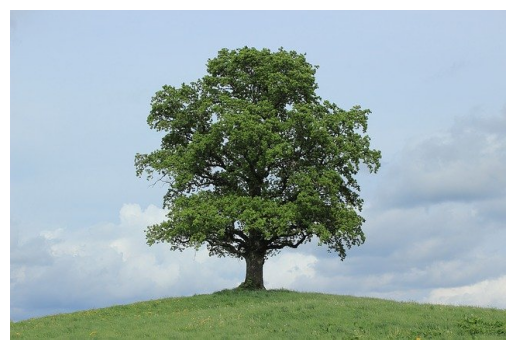

In [ ]:
import matplotlib.pyplot as plt #그래프,이미지를 그리는데 사용
import matplotlib.image as mpimg #이미지를 자루는 matplotlib 모듈

img = mpimg.imread('tree-1.jpg') #이미지 읽어오기
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
img = cv2.imread('tree-1.jpg') #이미지 읽어오기

In [5]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  #이미지의 색상 공간을 변환
#cv2.COLOR_BGR2GRAY RGB 색상 공간을 흑백으로 변환

In [12]:
img.shape, img_gray.shape

((426, 640, 3), (426, 640))

(np.float64(-0.5), np.float64(639.5), np.float64(425.5), np.float64(-0.5))

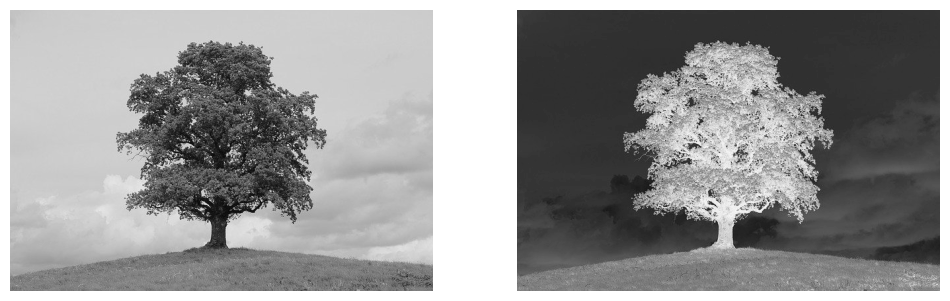

In [ ]:
plt.figure(figsize=(12,8)) #12인치x8인피 크기 
plt.subplot(121)
plt.imshow(img_gray, cmap='gray') #cmap='gray' 0에 가까운 색은 검은색, 255에 가까운 색은 흰색
plt.axis('off')
plt.subplot(122)
plt.imshow(255-img_gray, cmap='gray') #255 빼면 흰색->검정, 검정->흰색
plt.axis('off')

(np.float64(-0.5), np.float64(639.5), np.float64(425.5), np.float64(-0.5))

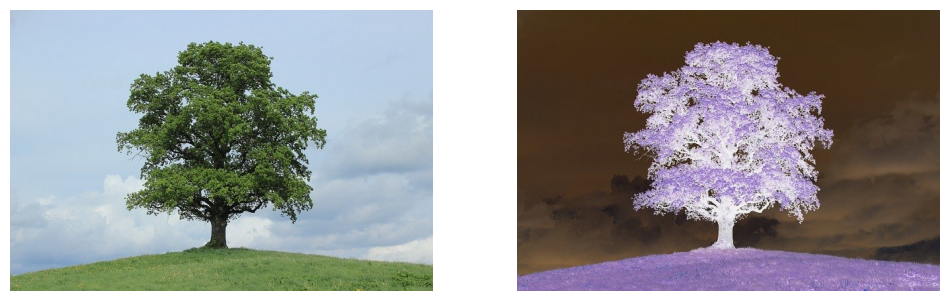

In [8]:
plt.figure(figsize=(12,8))
plt.subplot(121)
plt.imshow(img[:,:,::-1]) #OpenCV는 이미지를 BGR, RGB로 바꿔줌 ::-1
plt.axis('off')
plt.subplot(122)
plt.imshow(255-img[:,:,::-1], cmap='gray') #색상 채널을 반전, 색상채널을 회색 값으로 변환 
plt.axis('off')

In [ ]:
def onMouseColorGray(event, x, y, flags, param):
    # local namespace
    if event == cv2.EVENT_RBUTTONUP: #우클릭
        cv2.imshow(winName, img_gray) #그레이스케일 이미지로 표시
    elif event == cv2.EVENT_LBUTTONUP: #좌클릭
        cv2.imshow(winName, img) #원본 이미지 표시

# main body namespace
img = cv2.imread('tree-1.jpg') #이미지 읽어오기
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #회색으로 바꾸기
winName = 'color & gray'
cv2.imshow(winName, img)
cv2.setMouseCallback(winName, onMouseColorGray) #마우스이벤트를 처리
while cv2.waitKey(0) != ord('q'): #사용자가 누른게 q가 아닐때 까지 계속 반복
    pass
cv2.destroyAllWindows() #모든창 닫기


In [ ]:
cv2dir = dir(cv2)
[e for e in cv2dir if 'EVENT' in e] #cv2 모듈에서 EVENT와 관련된 것

['EVENT_FLAG_ALTKEY',
 'EVENT_FLAG_CTRLKEY',
 'EVENT_FLAG_LBUTTON',
 'EVENT_FLAG_MBUTTON',
 'EVENT_FLAG_RBUTTON',
 'EVENT_FLAG_SHIFTKEY',
 'EVENT_LBUTTONDBLCLK',
 'EVENT_LBUTTONDOWN',
 'EVENT_LBUTTONUP',
 'EVENT_MBUTTONDBLCLK',
 'EVENT_MBUTTONDOWN',
 'EVENT_MBUTTONUP',
 'EVENT_MOUSEHWHEEL',
 'EVENT_MOUSEMOVE',
 'EVENT_MOUSEWHEEL',
 'EVENT_RBUTTONDBLCLK',
 'EVENT_RBUTTONDOWN',
 'EVENT_RBUTTONUP']

In [ ]:
def onMouseColorGrayInvert(event, x, y, flags, param):
    # local namespace
    global gray_mode, color_mode
    if event == cv2.EVENT_LBUTTONUP: #좌클릭
        if gray_mode == 'NORMAL': #NORMAL이면
            cv2.imshow(winName, img_gray_inv) #반전된 이미지
            gray_mode = 'INVERT' 
        elif gray_mode == 'INVERT': #INVERT이면
            cv2.imshow(winName, img_gray) #반전되지 않은 이미지
            gray_mode = 'NORMAL' 
    elif event == cv2.EVENT_RBUTTONUP: #우클릭
        if color_mode == 'NORMAL':
            cv2.imshow(winName, img_inv) #반전된이미지
            color_mode = 'INVERT'
        elif color_mode == 'INVERT':
            cv2.imshow(winName, img) #반전되지 않은 이미지
            color_mode = 'NORMAL'

# main body namespace
img = cv2.imread('tree-1.jpg') #이미지 읽어오기
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #그레이스케일로 변환
img_inv = 255 - img #반전
img_gray_inv = 255 - img_gray #반전

color_mode = 'NORMAL'
gray_mode = 'NORMAL'

winName = 'color & gray'
cv2.imshow(winName, img) #이미지 보여주기
cv2.setMouseCallback(winName, onMouseColorGrayInvert) #마우스 이벤트 발생할때마다 
while cv2.waitKey(0) != ord('q'):
    pass
cv2.destroyAllWindows()


### 문제 6: 

OpenCV의 waitKey 함수를 이용하여 예제 1에서 영상이 변화 과정을 반수동으로 변경할 수 있도록 프로그램을 수정하라.

단, 입력한 키에 따른 동작은 다음과 같다.

- '1': $\alpha = 0. \rightarrow 1.00$,  tree-1 $\rightarrow$ tree-2, (tree-2에서 정지)
- '2': $\alpha = 0. \rightarrow 1.00$,  tree-2 $\rightarrow$ tree-3, (tree-3에서 정지)
- '3': $\alpha = 0. \rightarrow 1.00$,  tree-3 $\rightarrow$ tree-4, (tree-4에서 정지)
- '4': $\alpha = 0. \rightarrow 1.00$,  tree-4 $\rightarrow$ tree-1, (tree-1에서 정지)
- 'q': 프로그램 종료



In [ ]:
import cv2
import numpy as np
import os

def load_image(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File {filename} does not exist")
    img = cv2.imread(filename) #이미지를 넘파이 배열로 반환
    if img is None: 
        raise ValueError(f"Could not load {filename}")
    return img

def show_blended(start_img, end_img, d_weight, duration, windowName):
    for alpha in np.arange(0, 1 + d_weight, d_weight):  
        blended = (1 - alpha) * start_img + alpha * end_img #이미지 블렌딩
        cv2.imshow(windowName, blended.astype(np.uint8))
        if cv2.waitKey(duration) == ord('q'):  # 'q' 입력하면 즉시 종료
            return


filenames = [f'tree-{n}.jpg' for n in range(1, 5)]
trees = [load_image(filename) for filename in filenames] #4개의 넘파이 배열 저장


cv2.namedWindow("Blended Images", cv2.WINDOW_AUTOSIZE) #윈도우 생성

show_blended(trees[0], trees[1], 0.01, 50, "Blended Images")

while True:
    key = cv2.waitKey(0)  # 키 입력 대기 (무한정)
    
    if key == ord('1'): #1 누르면 1->2
        show_blended(trees[0], trees[1], 0.01, 50, "Blended Images")
    elif key == ord('2'): #2 누르면 2->3
        show_blended(trees[1], trees[2], 0.01, 50, "Blended Images")
    elif key == ord('3'): #3 누르면 3->4
        show_blended(trees[2], trees[3], 0.01, 50, "Blended Images")
    elif key == ord('4'): #4 누르면 4->1
        show_blended(trees[3], trees[0], 0.01, 50, "Blended Images")
    elif key == ord('q'):  # 'q' 입력하면 종료
        break

cv2.destroyAllWindows()

### 문제 7.

OpenCV의 trackbar를 사용하여 예제 1에서 영상이 변화 과정을 수동으로 변경할 수 있도록 프로그램을 수정하라.

단, Trackbar의 범위를 0부터 400까지 설정하고, trackbar에서 1이 변하면 $\alpha$ 값이 0.01이 변하도록 변환하라. trackbar의 변환 범위는 다음과 같다.

- Trackbar $= 0 \rightarrow 100$:   $\alpha = 0. \rightarrow 1.00$,  tree-1 $\rightarrow$ tree-2
- Trackbar $= 100 \rightarrow 200$: $\alpha = 0. \rightarrow 1.00$,  tree-2 $\rightarrow$ tree-3
- Trackbar $= 200 \rightarrow 300$: $\alpha = 0. \rightarrow 1.00$,  tree-3 $\rightarrow$ tree-4
- Trackbar $= 300 \rightarrow 400$: $\alpha = 0. \rightarrow 1.00$,  tree-4 $\rightarrow$ tree-1

그리고 'q'를 누르면 프로그램이 종료되어야 한다.

In [9]:
import cv2
import numpy as np

# 이미지 불러오기
img1 = cv2.imread('tree-1.jpg')
img2 = cv2.imread('tree-2.jpg')
img3 = cv2.imread('tree-3.jpg')
img4 = cv2.imread('tree-4.jpg')

# 트랙바를 사용하여 alpha 값이 0에서 1로 변하도록 설정하는 함수
def on_trackbar(val):
    global img1, img2, img3, img4
    
    if 0 <= val < 100: #0~100
        alpha = val / 100.0  
        beta = 1 - alpha 
        img_result = cv2.addWeighted(img1, alpha, img2, beta, 0) #두 개의 이미지를 섞어주는 함수
        #첫번쨰이미지, 첫번째이미지 가중치, 두번쨰 이미지, 두번쨰이미지가중치, 밝기조정값
    elif 100 <= val < 200: #100~200
        alpha = (val - 100) / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img2, alpha, img3, beta, 0)
    elif 200 <= val < 300: #200~300
        alpha = (val - 200) / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img3, alpha, img4, beta, 0)
    elif 300 <= val <= 400: #300~400
        alpha = (val - 300) / 100.0  
        beta = 1 - alpha
        img_result = cv2.addWeighted(img4, alpha, img1, beta, 0)
    
    cv2.imshow('Transitioning Image', img_result)

# 윈도우 창 생성
cv2.namedWindow('Transitioning Image')

# 트랙바 생성
cv2.createTrackbar('Alpha', 'Transitioning Image', 0, 400, on_trackbar)

# 트랙바의 초기값을 0으로 설정
on_trackbar(0)

while True:
    # 'q' 키가 눌리면 종료
    if cv2.waitKey(0) != ord('q'):
        break

# 모든 창 닫기
cv2.destroyAllWindows()


In [ ]:
def onMouseClick(event, x, y, flags, param): #마우스 이벤트가 발생할 때마다 호출
    global pt1, pt2, img_a
    if event == cv2.EVENT_LBUTTONUP: #왼쪽버튼 뗄 때
        pt1 = x, y #마우스 클릭한 좌표를 새로운 사각형 시작점
        pt2 = pt1 + rect #우하단 좌표
        img_a = img.copy() #이미지 복사
        cv2.rectangle(img_a, pt1, pt2, white, cv2.LINE_4) #사각형 그리기, cv2.LINE_4 선 굵기 4
        cropped_img = img[pt1[1]:pt2[1], pt1[0]:pt2[0],:] #세로영역:가로영역:모든컬러포함
        cv2.imshow("Cropped", cropped_img) #잘라낸 이미지 표시
        cv2.imshow("Image", img_a) #사각형이 그려진 복사본 이미지 표시

white = (255, 255, 255) #사각형을 흰색
img = cv2.imread("bird.png") #이미지 불러오기

pt1 = np.array([30, 30]) # (x, y) 사각형의 시작 위치(좌상단 좌표)
rect =  np.array([300, 200]) # (x, y) 사각형의 너비, 높이
pt2 = pt1 + rect #사각형의 우하단 좌표

img_a = img.copy() #이미지 복사
cv2.rectangle(img_a, pt1, rect, white, cv2.LINE_4) #사격형 그리기

cropped_img = img[pt1[0]:pt1[0]+rect[1],pt1[1]:pt1[1]+rect[0],:]
cv2.imshow("Cropped", cropped_img)
cv2.imshow("Image", img_a)

cv2.setMouseCallback("Image", onMouseClick)

while cv2.waitKey(0) != ord('q'): #q 누르면 종료
    pass


cv2.destroyAllWindows() #모든 창 닫기

In [14]:
%matplotlib qt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpl
from matplotlib.patches import Rectangle

# 전역 변수
pt1 = np.array([30, 30])  # 초기 좌표 (x, y)
rect = np.array([300, 200])  # 사각형 크기 (width, height)
img = mpl.imread("bird.png") #이미지 읽어오기
img_a = img.copy() #이미지 복사


# 마우스 클릭 이벤트 처리 함수
def onMouseClick(event):
    global pt1, pt2, img_a_rgb
    if event.button == 1:  # 왼쪽 버튼 클릭
        pt1 = np.array([int(event.xdata), int(event.ydata)]) #클릭한 위치로 pt1 바꾸기
        pt2 = pt1 + rect 
        img_a = img.copy()  # 원본 복사
        cv2.rectangle(img_a, tuple(pt1), tuple(pt2), (255, 255, 255), thickness=4)
        img_a_rgb = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB) #BGR RGB로 바꾸기
        
        # 잘린 이미지
        cropped_img = img[pt1[1]:pt2[1], pt1[0]:pt2[0], :]
        cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)#RGB로 변환
        
        # Matplotlib로 업데이트
        ax1.imshow(img_a_rgb)
        ax1.patches.clear()  # 이전 사각형 제거
        ax1.add_patch(Rectangle(pt1, rect[0], rect[1], fill=False, edgecolor='white', linewidth=2))#새 사각형 추가
        ax2.imshow(cropped_img_rgb)
        plt.draw()

# 초기 사각형 그리기
cv2.rectangle(img_a, tuple(pt1), tuple(pt2), (255, 255, 255), thickness=4)
img_a_rgb = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
cropped_img = img[pt1[1]:pt2[1], pt1[0]:pt2[0], :]
cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

# Matplotlib figure 설정
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Image")
ax2.set_title("Cropped")
ax1.imshow(img_a_rgb)
ax1.add_patch(Rectangle(pt1, rect[0], rect[1], fill=False, edgecolor='white', linewidth=2))
ax2.imshow(cropped_img_rgb)

# 마우스 이벤트 연결
#fig.canvas.mpl_connect('button_release_event', onMouseClick)

# 'q'로 종료하기 위한 별도 처리 (Matplotlib는 cv2.waitKey와 다르게 동작)
print("Press 'q' in the Jupyter cell or interrupt the kernel to exit.")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Press 'q' in the Jupyter cell or interrupt the kernel to exit.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle

# Qt 백엔드 설정
%matplotlib qt

# 전역 변수
pt1 = np.array([30, 30])  # 초기 좌표 (x, y)
rect = np.array([300, 200])  # 사각형 크기 (width, height)
img = mpimg.imread("tree-1.jpg")  # Matplotlib로 이미지 읽기
img_a = img.copy()  # 이미지 복사

# 마우스 클릭 이벤트 처리 함수
def onMouseClick(event):
    global pt1, pt2, img_a, rect_patch
    if event.button == 1:  # 왼쪽 버튼 클릭
#        print(f"Mouse clicked at: ({event.xdata}, {event.ydata})")
        if event.xdata is not None and event.ydata is not None:
            pt1 = np.array([int(event.xdata), int(event.ydata)]) #클릭한 좌표
            pt2 = pt1 + rect #우하단 좌표 계산
            
            # 원본 이미지 복사
            img_a = img.copy()
            
            # 잘린 이미지 (범위 체크 추가)
            y1, y2 = max(0, pt1[1]), min(img.shape[0], pt2[1])
            #plt[1]이 항상 0 이상, plt2[1]이 이미지 세로 크기를 초과하지 않게
            x1, x2 = max(0, pt1[0]), min(img.shape[1], pt2[0])
            #plt[0]이 항상 0 이상, plt2[0]이 이미지 가로크기 초과하지 않게
            cropped_img = img[y1:y2, x1:x2] #해당 영역 잘라내기
            
            # 사각형 위치 업데이트
            rect_patch.set_xy(pt1)  # 기존 사각형 위치만 변경
            ax2.imshow(cropped_img)
            fig.canvas.draw() # 실시간 갱신

# 초기 잘린 이미지
pt2 = pt1 + rect
cropped_img = img[pt1[1]:pt2[1], pt1[0]:pt2[0]]

# Matplotlib figure 설정
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Image")
ax2.set_title("Cropped")

# 초기 이미지 표시
ax1.imshow(img_a)
rect_patch = Rectangle(pt1, rect[0], rect[1], fill=False, edgecolor='white', linewidth=2)
ax1.add_patch(rect_patch)
ax2.imshow(cropped_img)

# 마우스 이벤트 연결
cid = fig.canvas.mpl_connect('button_release_event', onMouseClick)

# 키보드 이벤트 처리 함수
def onKeyPress(event):
    if event.key == 'q':
        plt.close(fig)  # 'q'로 창 닫기

# 키보드 이벤트 연결
fig.canvas.mpl_connect('key_press_event', onKeyPress)

plt.show()